# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [1]:
# откройте данные: ваш код здесь
import pandas as pd

mail_data = pd.read_csv('C:\\IDE\\data\\Block_6\\spam_or_not_spam.csv')
mail_data.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [2]:
# рассчитайте частоты для классов : ваш код здесь

mail_data.groupby('label')['label'].count()

label
0    2500
1     500
Name: label, dtype: int64

C:\Users\Smoking Shop\AppData\Local\Temp\ipykernel_24960\1537336261.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=mail_data, x='label', palette='magma')


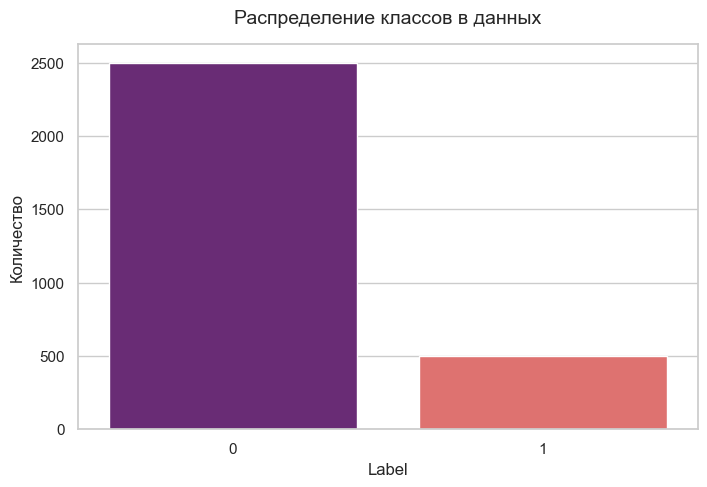

In [3]:
# визуализируйте результат: ваш код здесь

import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Построение графика
ax = sns.countplot(data=mail_data, x='label', palette='magma')

plt.title('Распределение классов в данных', fontsize=14, pad=15)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.show();

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [5]:
#ваш код здесь

import numpy as np

# Делаем копию наших данных
mail_data_clean = mail_data.copy()

# Заменяем пустые строки и строки из одних пробелов на NaN
mail_data_clean = mail_data_clean.replace(r'^\s*$', np.nan, regex=True)

# Удаляем все строки, содержащие NaN
mail_data_clean = mail_data_clean.dropna()


Переводим данные в векторный вид:

In [6]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(mail_data_clean["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [7]:
#ваш код здесь
# Посмотрим на количество новых признаков
print(len(vectorizer.get_feature_names_out()))

34116


## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [ ]:
#ваш код здесь
X = X
y = mail_data_clean['label']

0       0
1       0
2       0
3       0
4       0
       ..
2995    1
2996    1
2997    1
2998    1
2999    1
Name: label, Length: 2997, dtype: int64

Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [ ]:
#ваш код здесь
# Импортируем нужную библиотеку
from sklearn.model_selection import train_test_split
# Разделяем выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [13]:
#ваш код здесь
print(round(y_test.mean(),3))

0.165


## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [28]:
#ваш код здесь
# Импортируем необходимые библиотеки
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, precision_score, f1_score, RocCurveDisplay, roc_auc_score, roc_curve

# Обучаем модель
model = ComplementNB(alpha=0.01)
model.fit(X_train, y_train)
predicted = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [29]:
#ваш код здесь
print('Значение accuracy: ', round(accuracy_score(y_test, predicted),3))
print('Значение precision: ', round(precision_score(y_test, predicted),3))
print('Значение F1: ', round(f1_score(y_test, predicted),3))

Значение accuracy:  0.988
Значение precision:  1.0
Значение F1:  0.962


Нарисуйте ROC-кривую:

Значение ROC-кривой:    0.995


<Figure size 800x600 with 0 Axes>

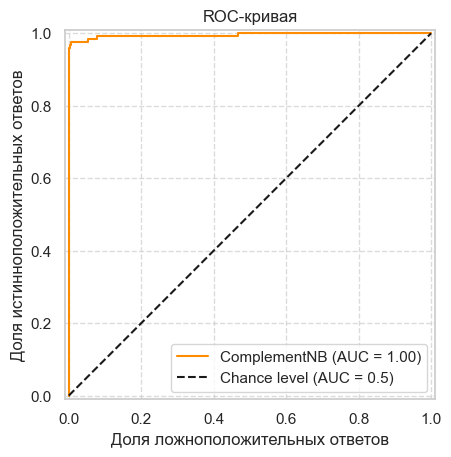

In [30]:
#ваш код здесь

# Расчет метрики площади для ROC-кривой
roc_auc = roc_auc_score(y_test, probabilities)
print("Значение ROC-кривой:   ", round(roc_auc, 3))

# Строим ROC-кривую
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test,
    probabilities,
    name="ComplementNB",
    color="darkorange",
    plot_chance_level=True,  # Добавляет пунктирную линию случайного угадывания
)

plt.title("ROC-кривая")
plt.xlabel("Доля ложноположительных ответов")
plt.ylabel("Доля истинноположительных ответов")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [35]:
#ваш код здесь
# импортируем нужную библиотеку
from sklearn.model_selection import GridSearchCV

alpha = np.logspace(-3, 2, 20) # задаем варианты параметра alpha (от 0.001 до 100)
param_grid = {"alpha": alpha} # задаем сетку гиперпараметров

# Обучаем модель с кросс-валидацией и сеткой гиперпараметров
grid_search = GridSearchCV(
    estimator=ComplementNB(),
    param_grid=param_grid,
    cv=5,
    scoring="f1",  # сравним значения метрики f1
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

# Выводим значения лучшей модели
best_model = grid_search.best_estimator_
print('Лучшие параметры модели: ', best_model)
# делаем предсказание
test_predictions = best_model.predict(X_test)
print("Качество лучшей модели: ", round(f1_score(y_test, test_predictions),3))

Лучшие параметры модели:  ComplementNB(alpha=0.42813323987193913)
Качество лучшей модели:  0.984
